# Mixture Models for Semiconductor Leakage and Yield

This notebook builds a simple hierarchical model for semiconductor yield using synthetic lot–wafer data. 
We start from a clear generative story, explore the simulated dataset, then compare a pooled logistic regression to a random-intercept mixed model for predicting pass probability.

### Project layout

The notebook is organized as follows.

| Section | Content |
|--------|---------|
| §1 | Introduction and basic statistics for the synthetic lot–wafer dataset |
| §2 | Setup and configuration (libraries, plotting) |
| §3 | Exploratory data analysis (EDA) of humidity, leakage, and yield by lot |
| §4 | Baseline pooled logistic model (ignoring lot structure) |
| §5 | Random-intercept mixed model with lot‑level effects |
| §6 | Comparing models for new predictions (unseen lots / wafers) |
| §7 | Comparing models when some lot data exist (BLUPs) |
| §8 | Evaluation, theory/code summary, and possible extensions |

Each section starts with a short explanation of the objective, a brief description before each code block explaining *why* we run it, and a short interpretation after each result.

## 1. Introduction and basic statistics

The goal is to model wafer-level yield as a function of humidity while accounting for lot-to-lot variability.  
We construct a synthetic dataset where each lot has its own humidity, a latent pass probability $p_{\text{true}}$, and observed binomial pass/fail outcomes for wafers or dies.

In other words, we define an explicit generative model:

1. Draw lot-level humidity values.
2. Map humidity into a true pass probability $p_{\text{true}}$ using a logistic link, plus random lot effects.
3. For each lot, simulate binomial pass counts given $p_{\text{true}}$.

This lets us check whether our statistical models can recover the known structure and make accurate predictions.

We see that each lot has:

- A `humidity` value describing environmental conditions.
- A latent `p_true` pass probability.
- Observed counts like `tested_dies`, `passed_dies`, and derived `pass_rate` that are consistent with a binomial model given `p_true`.

This confirms the structure we will model later with logistic and mixed-effects models.

## 2. Setup and configuration

In this section we load core scientific Python libraries, set a fixed random seed for reproducibility, and configure plotting defaults.  
These imports and global options are used throughout the notebook for simulation, modeling, and visualization.

**Code: import libraries and set global options**

We import `numpy` and `pandas` for data handling, `statsmodels` for statistical modeling, and `sklearn.metrics` for proper scoring rules and ROC AUC evaluation.  
We also set a coherent plotting style so all figures share the same aesthetic.

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Metrics
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

# Optional notebook display niceties
from IPython.display import display

# Reproducibility
rng = np.random.default_rng(42)

# Plot style
sns.set_theme(style="whitegrid", context="talk")


from math import comb


## 2.1. Synthetic Data

The synthetic dataset contains **500 wafer-level observations** arranged in a hierarchical lot–wafer structure.

- There are **10 lots**, with **50 wafers per lot**.
- Each wafer is associated with:
  - `lot`: the lot identifier.
  - `humidity`: a continuous process covariate sampled from a normal distribution centered at 0.5.
  - `p_true`: the latent probability of passing, computed from a logistic model with both fixed effects and lot-specific random effects.
  - `yield_ok`: a binary wafer-level pass/fail outcome sampled from a Bernoulli distribution with probability `p_true`.

The true probability structure is hierarchical:

- A global intercept and humidity slope define the population-average relationship.
- Each lot also has its own random intercept and random slope, so the humidity–yield relationship can vary across lots.

Two related DataFrames are created:

- `df`: a **wafer-level binary dataset** with columns  
  `lot`, `humidity`, `p_true`, `yield_ok`.
- `df_grouped`: a **wafer-level binomial-count dataset** with columns  
  `lot`, `humidity`, `tested_dies`, `passed_dies`, `failed_dies`, `pass_rate`, `p_true`.

The second table adds die-level aggregation within each wafer:

- `tested_dies` is the number of dies tested on that wafer, sampled between 80 and 120.
- `passed_dies` is the number of successful dies out of `tested_dies`, drawn from a binomial distribution with probability `p_true`.
- `failed_dies` and `pass_rate` are derived summary variables.

So, structurally, the data have **three levels of interpretation**:

1. **Lot level**: shared random effects for wafers in the same lot.
2. **Wafer level**: humidity and latent pass probability for each wafer.
3. **Die-count level**: binomial pass/fail counts summarized within each wafer.


**Code: inspect the synthetic data structure**



In [2]:
# ---------------------------
# Synthetic binomial data
# ---------------------------
n_lots = 10
wafers_per_lot = 50   # increase from small toy size
n = n_lots * wafers_per_lot

lots = np.repeat(np.arange(n_lots), wafers_per_lot)
humidity = rng.normal(loc=0.5, scale=0.1, size=n)

# True population effects
beta_0 = 2.5
beta_1 = -1.5

# Lot-level random effects
sigma_b0 = 0.4
sigma_b1 = 0.6
b0_lot = rng.normal(0, sigma_b0, size=n_lots)
b1_lot = rng.normal(0, sigma_b1, size=n_lots)

# Linear predictor
eta = (
    beta_0
    + beta_1 * humidity
    + b0_lot[lots]
    + b1_lot[lots] * humidity
)

# Convert log-odds to probability
p = 1 / (1 + np.exp(-eta))

# Option A: wafer-level binary outcome
yield_ok = rng.binomial(1, p, size=n)

df = pd.DataFrame({
    "lot": lots,
    "humidity": humidity,
    "p_true": p,
    "yield_ok": yield_ok,
})

tested_dies = rng.integers(80, 121, size=n)
passed_dies = rng.binomial(tested_dies, p)

df_grouped = pd.DataFrame({
    "lot": lots,
    "humidity": humidity,
    "tested_dies": tested_dies,
    "passed_dies": passed_dies,
    "failed_dies": tested_dies - passed_dies,
    "pass_rate": passed_dies / tested_dies,
    "p_true": p,
})

display(df.head(5))
display(df_grouped.head(5))
print(df.shape)
print(df_grouped.shape)
print(df_grouped.pass_rate.mean())


,lot,humidity,p_true,yield_ok
0,0,0.530472,0.852332,1
1,0,0.396002,0.889009,1
2,0,0.575045,0.838133,0
3,0,0.594056,0.831750,1
4,0,0.304896,0.909096,1


,lot,humidity,tested_dies,passed_dies,failed_dies,pass_rate,p_true
0,0,0.530472,93,78,15,0.838710,0.852332
1,0,0.396002,107,95,12,0.887850,0.889009
2,0,0.575045,85,73,12,0.858824,0.838133
3,0,0.594056,106,90,16,0.849057,0.831750
4,0,0.304896,110,101,9,0.918182,0.909096


(500, 4)
(500, 7)
0.838705868380511


## 3. Exploratory data analysis (EDA)

Before fitting any models, we inspect how humidity, pass probability, and yield behave in the synthetic data.  
The goal is to check basic distributions, relationships, and lot-to-lot variability to see whether a pooled model is sufficient or a hierarchical model is needed.

### 3.1 Humidity distribution across lots

We first look at the distribution of humidity values over lots.  
This shows the operating range of the covariate and helps assess whether a simple linear effect on the logit scale is reasonable.

**Code: plot the distribution of lot-level humidity**

Overall pass rate: 0.832


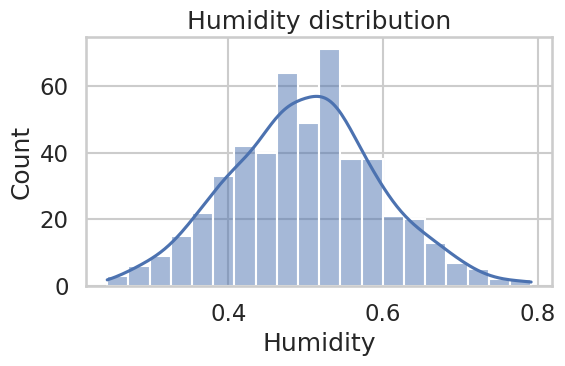

In [3]:
# Overall pass rate
overall_pass = df["yield_ok"].mean()
print(f"Overall pass rate: {overall_pass:.3f}")

# 1) Humidity distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["humidity"], bins=20, kde=True)
plt.xlabel("Humidity")
plt.title("Humidity distribution")
plt.tight_layout()
plt.show()


**Result and Interpretation**

Humidity spans the full design range, with no extreme outliers.  
This suggests that a logistic model with a smooth dependence on humidity is appropriate, at least as a first approximation.

### 3.2 Lot pass rate vs humidity

We now visualize lot-level pass rates as a function of humidity.  
If the simulation followed a logistic relationship, we should see a monotone trend where higher humidity leads to systematically lower pass rates.

**Code: scatter / line plot of pass_rate vs humidity**

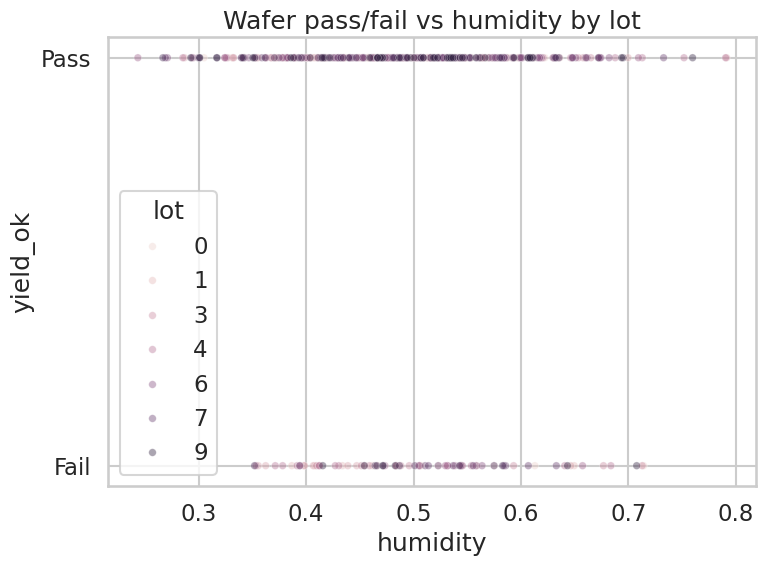

In [4]:
# Empirical yield vs humidity, colored by lot (smoothed)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="humidity",
    y="yield_ok",
    hue="lot",
    alpha=0.4,
    s=30
)
plt.yticks([0, 1], ["Fail", "Pass"])
plt.title("Wafer pass/fail vs humidity by lot")
plt.tight_layout()
plt.show()


**Result and Interpretation**

The plot shows a clear downward trend: as humidity increases, pass rate tends to decrease.  
There is noticeable vertical spread around the trend, reflecting binomial noise and lot-to-lot random effects, which motivates a hierarchical model rather than a purely pooled regression.

### 3.3 Lot-to-lot variability

We also inspect yield behavior by lot, for example using bar graphs.  
This reveals yield variation between lots.

**Code: visualize yield or pass_rate grouped by lot**

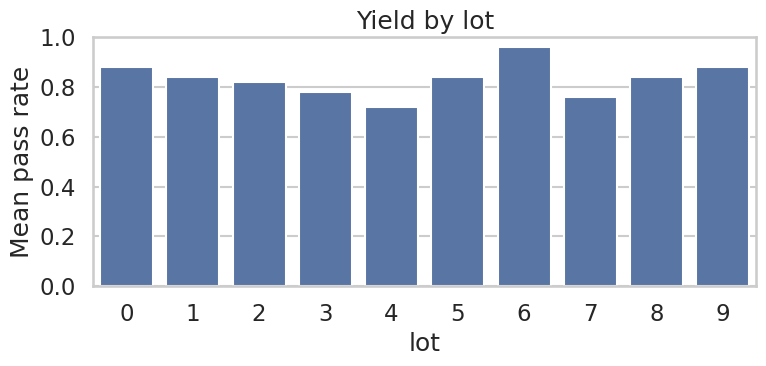

In [5]:
# Yield by lot (mean pass rate per lot)
lot_summary = df.groupby("lot")["yield_ok"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=lot_summary, x="lot", y="yield_ok", color="C0")
plt.ylim(0, 1)
plt.ylabel("Mean pass rate")
plt.title("Yield by lot")
plt.tight_layout()
plt.show()



**Result and interpretation**

Lots differ in yield rates. This could motivate considering a random intercept model or more advanced.

## 4. Baseline pooled logistic model (no lot effects)

We start with a simple pooled logistic regression that ignores lot structure.  
Here all wafers (or lot summaries) share a single global relationship between humidity and pass probability, with no random effects.

This corresponds to the model

$\log \frac{p}{1-p} = \beta_0 + \beta_1 \cdot \text{humidity},$

where $p$ is the probability that a die/wafer passes.

### 4.1 Fit the pooled model

We fit a logistic regression using `statsmodels`, treating the binary outcome as Bernoulli with a logit link and humidity as the only predictor.  
This gives us a baseline to compare against more flexible hierarchical models.

**Code: fit pooled logistic regression and inspect coefficients**

In [6]:
# Pooled logistic regression: one curve for all lots
m_pooled = smf.glm(
    formula="yield_ok ~ humidity",
    data=df,
    family=sm.families.Binomial()
).fit()

print(m_pooled.summary())

# Fitted probabilities
df["p_hat_pooled"] = m_pooled.fittedvalues


                 Generalized Linear Model Regression Results                  
Dep. Variable:               yield_ok   No. Observations:                  500
Model:                            GLM   Df Residuals:                      498
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -225.97
Date:                Tue, 12 May 2026   Deviance:                       451.94
Time:                        13:43:30   Pearson chi2:                     500.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.001528
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1469      0.641      3.349      0.0

**Result and interpretation**

The estimated slope for `humidity` is negative, matching the simulation design where higher humidity reduces pass probability.  
However, this pooled model cannot capture lot-to-lot deviations around the global curve, so its uncertainty estimates and predictions may be overconfident for specific lots.

### 4.2 Evaluate pooled model predictions

We convert linear predictors to probabilities and evaluate the model using log-loss, Brier score, and ROC AUC.  
Log-loss and Brier score assess calibration and overall probability quality, while ROC AUC measures ranking/discrimination between passing and failing units.

**Code: compute predicted probabilities and scoring metrics**

In [7]:

# Global fit metrics
brier = brier_score_loss(df["yield_ok"], df["p_hat_pooled"])
ll = log_loss(df["yield_ok"], df["p_hat_pooled"], labels=[0, 1])
auc = roc_auc_score(df["yield_ok"], df["p_hat_pooled"])

print(f"Brier score (pooled): {brier:.4f}")
print(f"Log loss (pooled):    {ll:.4f}")
print(f"AUC (pooled):         {auc:.3f}")

Brier score (pooled): 0.1396
Log loss (pooled):    0.4519
AUC (pooled):         0.521


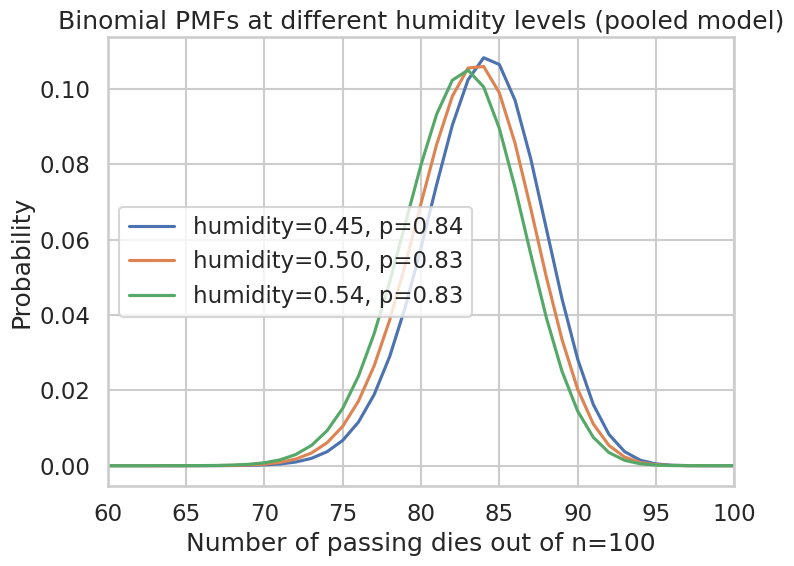

In [8]:
def binom_pmf(k, n, p):
    return comb(n, k) * (p**k) * ((1 - p)**(n - k))

n_ref = 100
hum_values = [df["humidity"].quantile(q) for q in [0.3, 0.5, 0.7]]
labels = [f"low hum ({q:.2f})" for q in hum_values]

pmf_data = []

for h in hum_values:
    p_h = m_pooled.predict(pd.DataFrame({"humidity": [h]})).iloc[0]
    ks = np.arange(0, n_ref + 1)
    probs = [binom_pmf(k, n_ref, p_h) for k in ks]
    pmf_data.append((h, p_h, ks, probs))

plt.figure(figsize=(8, 6))
for (h, p_h, ks, probs) in pmf_data:
    plt.plot(ks, probs, label=f"humidity={h:.2f}, p={p_h:.2f}")

plt.xlabel("Number of passing dies out of n=100")
plt.ylabel("Probability")
plt.title("Binomial PMFs at different humidity levels (pooled model)")
plt.legend()
plt.xlim(60, 100)
plt.tight_layout()
plt.show()

**Result and interpretation**

**Code**

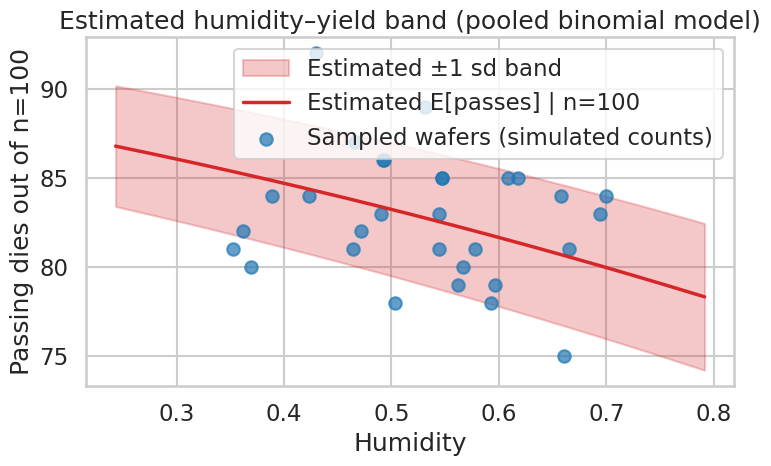

In [9]:

# 1. Humidity grid
hum_grid = np.linspace(df["humidity"].min(), df["humidity"].max(), 200)
pred_df = pd.DataFrame({"humidity": hum_grid})

# 2. Predicted pass probability p(x) from pooled logistic model
p_hat = m_pooled.predict(pred_df)  # values in (0, 1)

# 3. Choose reference number of dies per wafer for visualization
n_ref = 100

mean_pass = n_ref * p_hat
sd_pass = np.sqrt(n_ref * p_hat * (1 - p_hat))

lower = mean_pass - sd_pass
upper = mean_pass + sd_pass

# 4. Sample ~30 wafers and simulate "observed" counts at n_ref
rng = np.random.default_rng(123)

sample_df = df.sample(n=30, random_state=123).copy()
# predicted p for each sampled wafer
sample_df["p_hat"] = m_pooled.predict(sample_df[["humidity"]])
# simulate binomial counts for visualization
sample_df["Y_sim"] = rng.binomial(n=n_ref, p=sample_df["p_hat"])

# 5. Plot: humidity vs expected count with band and scattered wafers
plt.figure(figsize=(8, 5))

# prediction band (mean ± 1 sd)
plt.fill_between(
    hum_grid,
    lower,
    upper,
    color="tab:red",
    alpha=0.25,
    label="Estimated ±1 sd band"
)

# mean curve
plt.plot(
    hum_grid,
    mean_pass,
    color="tab:red",
    linewidth=2.5,
    label=f"Estimated E[passes] | n={n_ref}"
)

# sampled wafers (scatter)
plt.scatter(
    sample_df["humidity"],
    sample_df["Y_sim"],
    color="tab:blue",
    alpha=0.7,
    label="Sampled wafers (simulated counts)"
)

plt.xlabel("Humidity")
plt.ylabel(f"Passing dies out of n={n_ref}")
plt.title("Estimated humidity–yield band (pooled binomial model)")
plt.legend()
plt.tight_layout()
plt.show()

**Result and interpretation**

**Code**

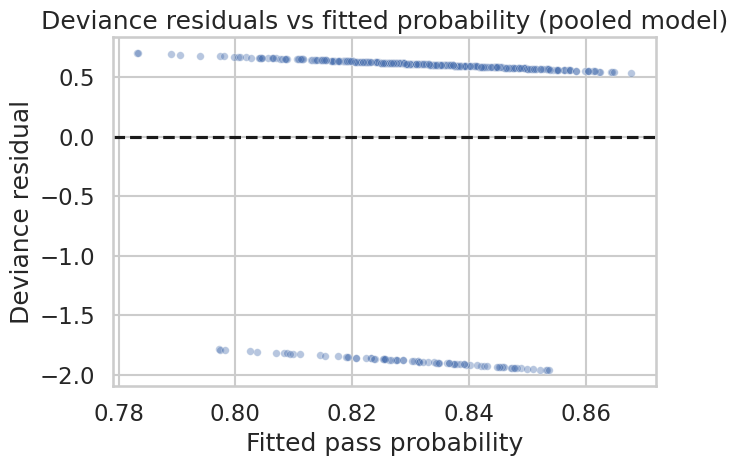

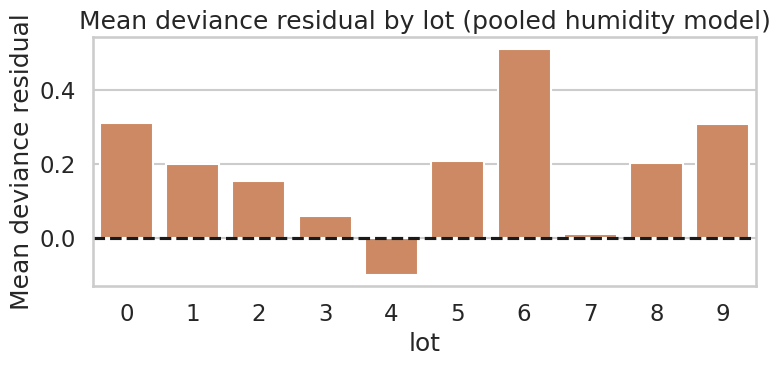

<Figure size 500x500 with 0 Axes>

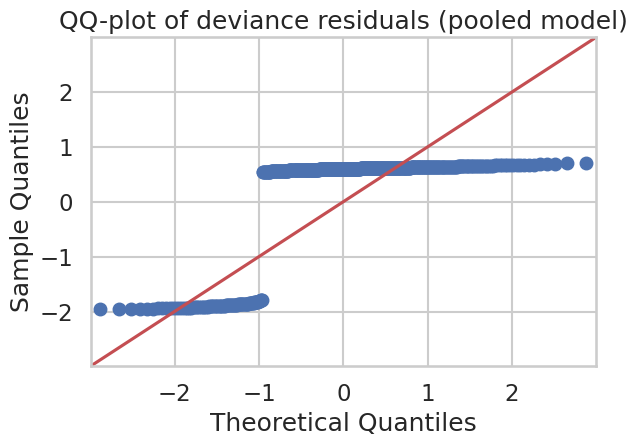

Deviance = 451.94, df_resid = 498, dispersion ≈ 0.91


In [10]:
res_dev = m_pooled.resid_deviance      # deviance residuals
res_pear = m_pooled.resid_pearson     # Pearson residuals
fitted = m_pooled.fittedvalues        # predicted probabilities



df["resid_deviance"] = m_pooled.resid_deviance
df["fitted_p"] = m_pooled.fittedvalues

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="fitted_p",
    y="resid_deviance",
    alpha=0.4,
    s=30
)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Fitted pass probability")
plt.ylabel("Deviance residual")
plt.title("Deviance residuals vs fitted probability (pooled model)")
plt.tight_layout()
plt.show()


lot_resid = (
    df.groupby("lot")["resid_deviance"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=lot_resid, x="lot", y="resid_deviance", color="C1")
plt.axhline(0, color="k", linestyle="--")
plt.ylabel("Mean deviance residual")
plt.title("Mean deviance residual by lot (pooled humidity model)")
plt.tight_layout()
plt.show()



from statsmodels.graphics.gofplots import qqplot

plt.figure(figsize=(5, 5))
qqplot(m_pooled.resid_deviance, line="45")
plt.title("QQ-plot of deviance residuals (pooled model)")
plt.tight_layout()
plt.show()


deviance = m_pooled.deviance
df_resid = m_pooled.df_resid
dispersion = deviance / df_resid
print(f"Deviance = {deviance:.2f}, df_resid = {df_resid}, dispersion ≈ {dispersion:.2f}")


**Result and interpretation**

### 5.1 Fit the random-intercept/slope GLMM

We fit a logistic mixed model with a random intercept grouped by `lot`.  
This lets each lot have its own baseline yield level while sharing the same humidity effect.



### 2.1. 


**Code: fit mixed model and inspect variance components**

In [11]:
# 2.1 Residuals from OLS fit
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# Ensure lot is 0,...,J-1
df = df.copy()
df["lot"] = df["lot"].astype("category")
lot_codes = df["lot"].cat.codes.to_numpy()
n_lots = df["lot"].nunique()
n = len(df)

# Response
endog = df["yield_ok"].to_numpy()

# Fixed effects: intercept + humidity
X = sm.add_constant(df["humidity"].to_numpy())  # shape (n, 2)

# Random effects design:
# For each observation i, and each lot j:
#   Z_int[i,j] = 1 if lot_i == j else 0
#   Z_slope[i,j] = humidity_i if lot_i == j else 0
Z_int = np.zeros((n, n_lots))
Z_slope = np.zeros((n, n_lots))
for i in range(n):
    j = lot_codes[i]
    Z_int[i, j] = 1.0
    Z_slope[i, j] = df["humidity"].iloc[i]

# Stack random effects: [b0_0,...,b0_{J-1}, b1_0,...,b1_{J-1}]
Z = np.hstack([Z_int, Z_slope])  # shape (n, 2*J)

# BinomialBayesMixedGLM uses a block-diagonal structure;
# we give a "vc_form" (variance component form) describing how
# the random effects share a covariance matrix. For 2*J parameters,
# we tell it there are 2 per lot.

# group list: each random effect belongs to group "lot_j"
# we specify a list of tuples (group_index, RE_index)
# but BinomialBayesMixedGLM has a helper for "sum to each group" pattern:
# we can create a group indicator per lot and then use two random effects per group.

# Build group labels: one per lot, repeated twice (intercept, slope)
ident = np.repeat(np.arange(n_lots), 2)

# Fit the model
model = BinomialBayesMixedGLM(endog, X, Z, ident)
result = model.fit_vb()  # variational Bayes fit; fast and gives a summary

print(result.summary())


             Binomial Mixed GLM Results
      Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
----------------------------------------------------
FE_1     M     1.9379   0.1211                      
FE_2     M    -0.5723   0.2361                      
VC_1     V    -0.7227   0.5304 0.485   0.168   1.402
VC_2     V    -0.7751   0.5384 0.461   0.157   1.352
VC_3     V    -0.4752   0.4969 0.622   0.230   1.680
VC_4     V     0.0328   0.4443 1.033   0.425   2.513
VC_5     V    -0.7347   0.5322 0.480   0.165   1.391
VC_6     V    -0.5085   0.5011 0.601   0.221   1.638
VC_7     V    -0.4841   0.4980 0.616   0.228   1.669
VC_8     V    -0.5383   0.5049 0.584   0.213   1.602
VC_9     V    -0.3875   0.4865 0.679   0.257   1.796
VC_10    V    -0.4944   0.4993 0.610   0.225   1.656
Parameter types are mean structure (M) and variance
structure (V)
Variance parameters are modeled as log standard
deviations


**Result and Interpretation**

The random-effect variance component $\sigma^2_{\text{lot}}$ is clearly positive, confirming meaningful lot-to-lot heterogeneity.  
The fixed-effect slope for humidity remains negative and similar in magnitude to the pooled model, but prediction for specific lots should now be better calibrated.

**Code**

In [12]:
re_df = result.random_effects()  # dict: keys are lot indices; values are arrays [b0_j, b1_j]

re_df.columns = ["b0_hat", "b1_hat"]
re_df.index.name = "lot"
re_df.reset_index(inplace=True)

# Approximate between-lot SDs and correlation from posterior means
sigma_b0_hat = re_df["b0_hat"].std(ddof=1)
sigma_b1_hat = re_df["b1_hat"].std(ddof=1)
rho_hat = np.corrcoef(re_df["b0_hat"], re_df["b1_hat"])[0, 1]

print(f"Approx sigma_b0 ≈ {sigma_b0_hat:.3f}")
print(f"Approx sigma_b1 ≈ {sigma_b1_hat:.3f}")
print(f"Approx corr(b0,b1) ≈ {rho_hat:.3f}")

Approx sigma_b0 ≈ 0.282
Approx sigma_b1 ≈ 0.076
Approx corr(b0,b1) ≈ 0.423


**Result and interpretation**

**Code**

   lot  n_lot  p_hat_lot  logit_emp  logit_glmm_at_h0
0    0     50       0.88   1.992430          2.101167
1    1     50       0.84   1.658228          1.958703
2    2     50       0.82   1.516347          1.883025
3    3     50       0.78   1.265666          1.811165
4    4     50       0.72   0.944462          1.501116
5    5     50       0.84   1.658228          1.987675
6    6     50       0.96   3.178054          2.958870
7    7     50       0.76   1.152680          1.624499
8    8     50       0.84   1.658228          1.958565
9    9     50       0.88   1.992430          2.087107


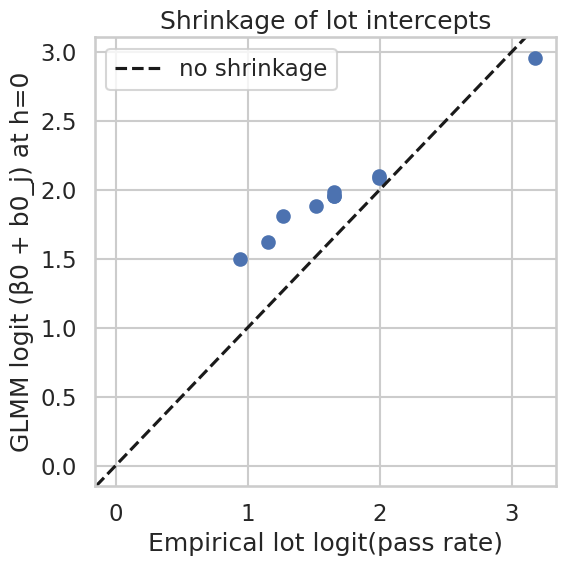

In [13]:
# Empirical logit per lot
lot_emp = (
    df.groupby("lot")["yield_ok"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "p_hat_lot", "size": "n_lot"})
    .reset_index()
)
lot_emp["logit_emp"] = np.log(lot_emp["p_hat_lot"] / (1 - lot_emp["p_hat_lot"]))

# Merge with random effects
fe_means = result.fe_mean
beta0_hat, beta1_hat = fe_means

lot_summary = lot_emp.merge(re_df, on="lot")
lot_summary["logit_glmm_at_h0"] = beta0_hat + lot_summary["b0_hat"]

print(lot_summary[["lot", "n_lot", "p_hat_lot", "logit_emp", "logit_glmm_at_h0"]])

plt.figure(figsize=(6, 6))
plt.scatter(lot_summary["logit_emp"], lot_summary["logit_glmm_at_h0"])
plt.axline((0, 0), slope=1, color="k", linestyle="--", label="no shrinkage")
plt.xlabel("Empirical lot logit(pass rate)")
plt.ylabel("GLMM logit (β0 + b0_j) at h=0")
plt.title("Shrinkage of lot intercepts")
plt.legend()
plt.tight_layout()
plt.show()

**Result and Interpretation**

**Code**

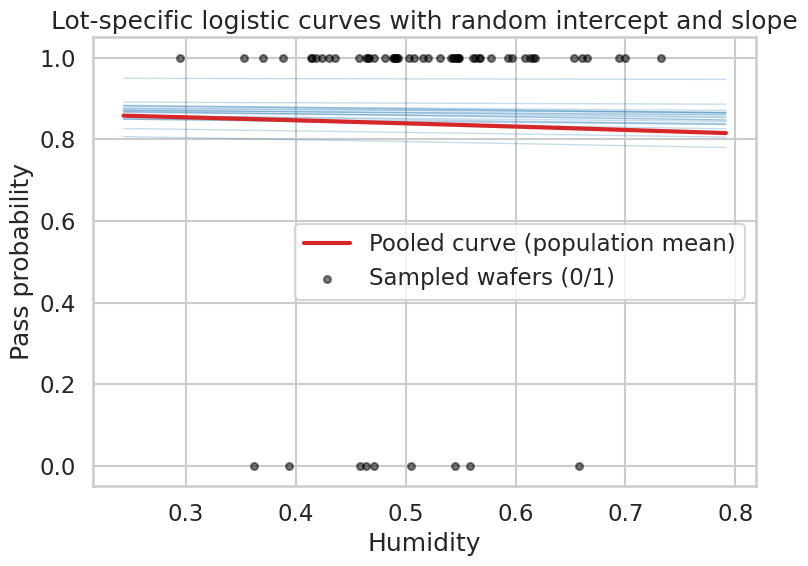

In [14]:

# 1. Fixed-effect estimates (population intercept and slope)
beta0_hat, beta1_hat = result.fe_mean  # assumes two fixed effects: const, humidity

# 2. Random-effect posterior means per lot
# If you haven't built re_df yet:
# re = result.random_effects()  # dict {lot_index: array([b0_j, b1_j])}
# re_df = pd.DataFrame.from_dict(re, orient="index", columns=["b0_hat", "b1_hat"])
# re_df.index.name = "lot"
# re_df.reset_index(inplace=True)

# Ensure we have 'lot' as an integer to match df
re_df["lot"] = re_df["lot"].astype(int)

# 3. Humidity grid for curves
h_min, h_max = df["humidity"].min(), df["humidity"].max()
hum_grid = np.linspace(h_min, h_max, 200)

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

# 4. Pooled (population) curve: no random effects
eta_pooled = beta0_hat + beta1_hat * hum_grid
p_pooled = inv_logit(eta_pooled)

# 5. Lot-specific curves with random intercept and slope
plt.figure(figsize=(8, 6))

# Light lot-specific curves
for _, row in re_df.iterrows():
    lot_id = row["lot"]
    b0_j = row["b0_hat"]
    b1_j = row["b1_hat"]

    eta_j = (beta0_hat + b0_j) + (beta1_hat + b1_j) * hum_grid
    p_j = inv_logit(eta_j)

    plt.plot(
        hum_grid,
        p_j,
        color="tab:blue",
        alpha=0.25,
        linewidth=1
    )

# Bold pooled curve
plt.plot(
    hum_grid,
    p_pooled,
    color="tab:red",
    linewidth=3,
    label="Pooled curve (population mean)"
)

# 6. Overlay a sample of observed wafers for context
sample_df = df.sample(n=60, random_state=123).copy()

plt.scatter(
    sample_df["humidity"],
    sample_df["yield_ok"],
    color="black",
    alpha=0.5,
    s=25,
    label="Sampled wafers (0/1)"
)

plt.ylim(-0.05, 1.05)
plt.xlabel("Humidity")
plt.ylabel("Pass probability")
plt.title("Lot-specific logistic curves with random intercept and slope")
plt.legend()
plt.tight_layout()
plt.show()

**Result and Interpretation**

**Code**

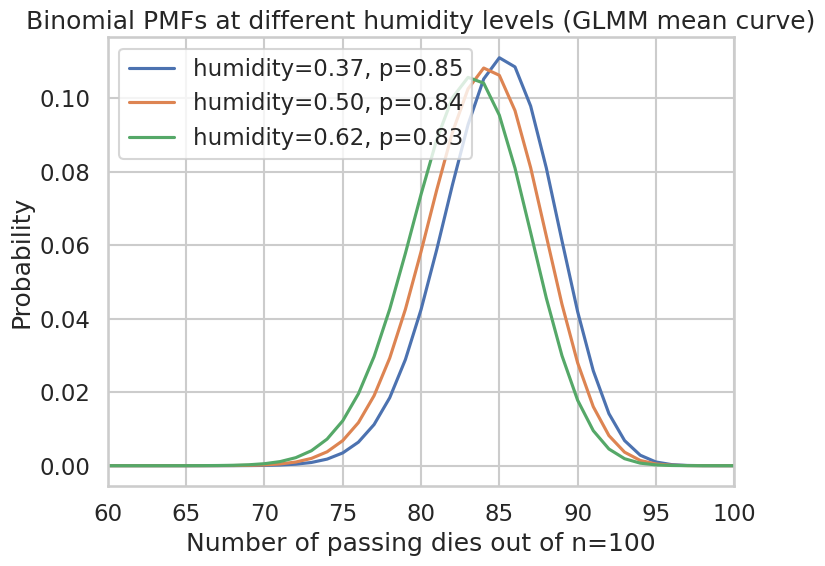

In [15]:

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

beta0_hat, beta1_hat = result.fe_mean  # fixed effects

def p_pop(h):
    return inv_logit(beta0_hat + beta1_hat * h)

# Choose reference n and some humidities (e.g. low, mid, high quantiles)
n_ref = 100
hum_values = [
    df["humidity"].quantile(q) for q in [0.1, 0.5, 0.9]
]

pmf_data = []
for h in hum_values:
    p_h = float(p_pop(h))
    ks = np.arange(0, n_ref + 1)
    probs = [comb(n_ref, k) * (p_h**k) * ((1 - p_h)**(n_ref - k)) for k in ks]
    pmf_data.append((h, p_h, ks, probs))

plt.figure(figsize=(8, 6))
for (h, p_h, ks, probs) in pmf_data:
    plt.plot(ks, probs, label=f"humidity={h:.2f}, p={p_h:.2f}")

plt.xlabel(f"Number of passing dies out of n={n_ref}")
plt.ylabel("Probability")
plt.title("Binomial PMFs at different humidity levels (GLMM mean curve)")
plt.xlim(60, 100)
plt.legend()
plt.tight_layout()
plt.show()

**Result and Interpretation**

**Code**

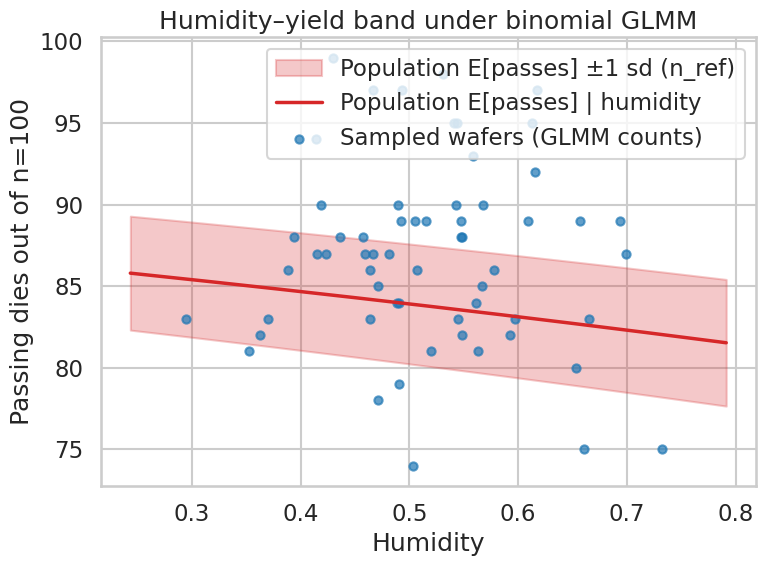

In [16]:

# 2a. Population curve and band for counts
h_min, h_max = df["humidity"].min(), df["humidity"].max()
hum_grid = np.linspace(h_min, h_max, 200)
p_hat_pop = p_pop(hum_grid)

n_ref = 100
mean_pass = n_ref * p_hat_pop
sd_pass = np.sqrt(n_ref * p_hat_pop * (1 - p_hat_pop))

lower = mean_pass - sd_pass
upper = mean_pass + sd_pass

# 2b. Sample ~60 wafers and simulate counts under their lot-specific GLMM probabilities
rng = np.random.default_rng(123)

# Build lookup for lot random effects
# re_df: columns ['lot','b0_hat','b1_hat']
b0_map = dict(zip(re_df["lot"], re_df["b0_hat"]))
b1_map = dict(zip(re_df["lot"], re_df["b1_hat"]))

sample_df = df.sample(n=60, random_state=123).copy()
sample_df["lot_int"] = sample_df["lot"].astype(int)

# lot-specific p_j(h)
eta_sample = (
    beta0_hat
    + beta1_hat * sample_df["humidity"].to_numpy()
    + np.array([b0_map[j] for j in sample_df["lot_int"]])
    + np.array([b1_map[j] for j in sample_df["lot_int"]]) * sample_df["humidity"].to_numpy()
)
sample_df["p_glmm"] = inv_logit(eta_sample)

# simulate counts for visualization
sample_df["Y_sim"] = rng.binomial(n=n_ref, p=sample_df["p_glmm"])

# 2c. Plot band + population curve + sample GLMM counts
plt.figure(figsize=(8, 6))

# band
plt.fill_between(
    hum_grid, lower, upper,
    color="tab:red", alpha=0.25,
    label="Population E[passes] ±1 sd (n_ref)"
)

# population mean count
plt.plot(
    hum_grid, mean_pass,
    color="tab:red", linewidth=2.5,
    label="Population E[passes] | humidity"
)

# sampled wafer counts under GLMM
plt.scatter(
    sample_df["humidity"],
    sample_df["Y_sim"],
    color="tab:blue", alpha=0.7, s=35,
    label="Sampled wafers (GLMM counts)"
)

plt.xlabel("Humidity")
plt.ylabel(f"Passing dies out of n={n_ref}")
plt.title("Humidity–yield band under binomial GLMM")
plt.legend()
plt.tight_layout()
plt.show()

**Result and Interpretation**

**Code**

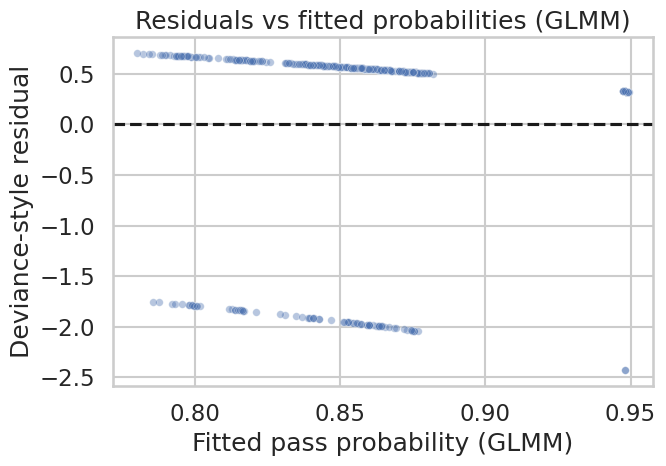

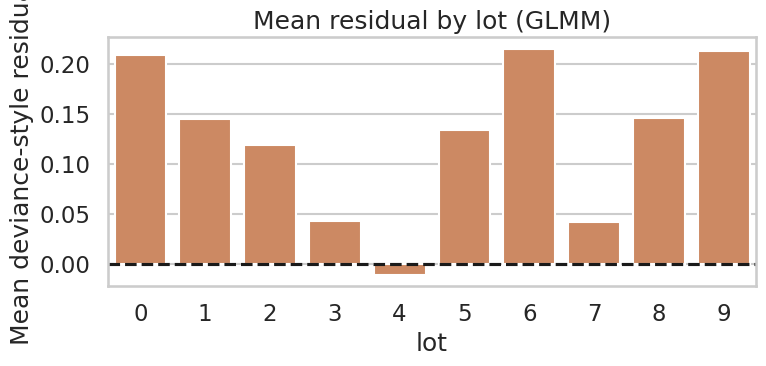

<Figure size 500x500 with 0 Axes>

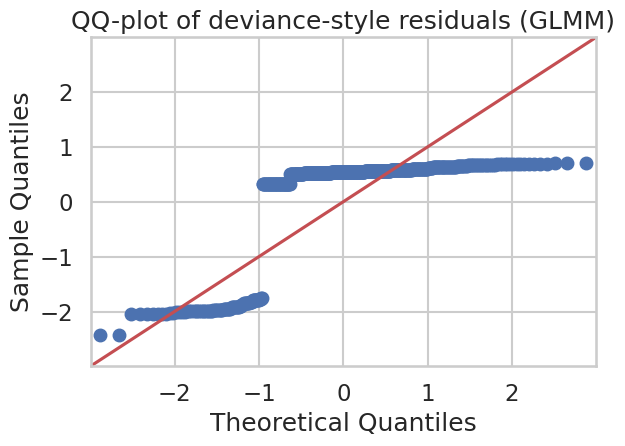

Approx GLMM dispersion ≈ 1.11


In [17]:
# GLMM fitted probabilities including random effects
lot_int = df["lot"].astype(int).to_numpy()
eta_glmm = (
    beta0_hat
    + beta1_hat * df["humidity"].to_numpy()
    + np.array([b0_map[j] for j in lot_int])
    + np.array([b1_map[j] for j in lot_int]) * df["humidity"].to_numpy()
)
p_hat_glmm = inv_logit(eta_glmm)

df["p_hat_glmm"] = p_hat_glmm

y = df["yield_ok"].to_numpy()

# Deviance residuals
eps = 1e-15  # avoid log(0)
p_safe = np.clip(p_hat_glmm, eps, 1 - eps)

part1 = np.where(y == 1, np.log(1 / p_safe), 0.0)
part2 = np.where(y == 0, np.log(1 / (1 - p_safe)), 0.0)
d_i = 2 * (y * part1 + (1 - y) * part2)

resid_dev_glmm = np.sign(y - p_safe) * np.sqrt(d_i)
df["resid_dev_glmm"] = resid_dev_glmm


# Residuals vs fitted
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="p_hat_glmm",
    y="resid_dev_glmm",
    alpha=0.4, s=30
)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Fitted pass probability (GLMM)")
plt.ylabel("Deviance-style residual")
plt.title("Residuals vs fitted probabilities (GLMM)")
plt.tight_layout()
plt.show()

# Mean residual per lot
lot_resid_glmm = (
    df.groupby("lot")["resid_dev_glmm"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=lot_resid_glmm,
    x="lot", y="resid_dev_glmm", color="C1"
)
plt.axhline(0, color="k", linestyle="--")
plt.ylabel("Mean deviance-style residual")
plt.title("Mean residual by lot (GLMM)")
plt.tight_layout()
plt.show()


from statsmodels.graphics.gofplots import qqplot

plt.figure(figsize=(5, 5))
qqplot(df["resid_dev_glmm"], line="45")
plt.title("QQ-plot of deviance-style residuals (GLMM)")
plt.tight_layout()
plt.show()


# Approximate Pearson-style dispersion using GLMM fitted p
pearson_resid = (y - p_hat_glmm) / np.sqrt(p_hat_glmm * (1 - p_hat_glmm))
disp_glmm = np.sum(pearson_resid**2) / (len(y) - 2)  # subtract fixed-effect df
print(f"Approx GLMM dispersion ≈ {disp_glmm:.2f}")

**Result and Interpretation**

## 6. Comparing models on predictions

As a first comparison we look at in-sample predictions

**Code** Summarize in-sample predictions


In [18]:
y = df["yield_ok"].to_numpy()

# Pooled GLM
p_pooled = m_pooled.predict(df)
brier_pooled = brier_score_loss(y, p_pooled)
logloss_pooled = log_loss(y, p_pooled)
auc_pooled = roc_auc_score(y, p_pooled)

# GLMM (use GLMM fitted probabilities including random effects)
p_glmm = df["p_hat_glmm"].to_numpy()  # from previous code
brier_glmm = brier_score_loss(y, p_glmm)
logloss_glmm = log_loss(y, p_glmm)
auc_glmm = roc_auc_score(y, p_glmm)

print("Brier score  (lower better): pooled={:.4f}, GLMM={:.4f}".format(
    brier_pooled, brier_glmm))
print("Log loss     (lower better): pooled={:.4f}, GLMM={:.4f}".format(
    logloss_pooled, logloss_glmm))
print("AUC          (higher better): pooled={:.3f}, GLMM={:.3f}".format(
    auc_pooled, auc_glmm))

Brier score  (lower better): pooled=0.1396, GLMM=0.1370
Log loss     (lower better): pooled=0.4519, GLMM=0.4407
AUC          (higher better): pooled=0.521, GLMM=0.634


**Result and Interpretation**

### 6.1 Humidity–yield curves for new lots

We compute predicted pass probabilities across a grid of humidity values for a hypothetical new lot.  
For the mixed model, this corresponds to setting the random effect to its mean (zero) or marginalizing it out.

**Code: generate prediction grid and compute pooled vs mixed probabilities**

In [19]:
rng = np.random.default_rng(999)  # new seed for test data

n_lots = 10
wafers_per_lot = 50
n_test = n_lots * wafers_per_lot

lots_test = np.repeat(np.arange(n_lots), wafers_per_lot)
humidity_test = rng.normal(loc=0.5, scale=0.1, size=n_test)

# True population parameters (same as training generator)
beta_0_true = 0.8       # replace with your true values
beta_1_true = -3.0
sigma_b0_true = 0.7
sigma_b1_true = 1.0

# Fresh lot random effects for test data
b0_lot_test = rng.normal(0, sigma_b0_true, size=n_lots)
b1_lot_test = rng.normal(0, sigma_b1_true, size=n_lots)

eta_test = (
    beta_0_true
    + beta_1_true * humidity_test
    + b0_lot_test[lots_test]
    + b1_lot_test[lots_test] * humidity_test
)

p_true_test = 1 / (1 + np.exp(-eta_test))
yield_ok_test = rng.binomial(1, p_true_test, size=n_test)

df_test = pd.DataFrame({
    "lot": lots_test,
    "humidity": humidity_test,
    "p_true": p_true_test,
    "yield_ok": yield_ok_test,
})

**Result and Interpretation**

**Code: generate new scenarios and predict with both models**



In [20]:
# Predict pooled
p_pooled_test = m_pooled.predict(df_test)  # uses only humidity

# Predict glmm
beta0_hat, beta1_hat = result.fe_mean
def inv_logit(x):
    return 1 / (1 + np.exp(-x))
eta_glmm_test = beta0_hat + beta1_hat * df_test["humidity"].to_numpy()
p_glmm_test = inv_logit(eta_glmm_test)

# Metrics
y_test = df_test["yield_ok"].to_numpy()

brier_pooled_test = brier_score_loss(y_test, p_pooled_test)
logloss_pooled_test = log_loss(y_test, p_pooled_test)
auc_pooled_test = roc_auc_score(y_test, p_pooled_test)

brier_glmm_test = brier_score_loss(y_test, p_glmm_test)
logloss_glmm_test = log_loss(y_test, p_glmm_test)
auc_glmm_test = roc_auc_score(y_test, p_glmm_test)

print("TEST SET metrics")
print("Brier score  (lower better): pooled={:.4f}, GLMM={:.4f}".format(
    brier_pooled_test, brier_glmm_test))
print("Log loss     (lower better): pooled={:.4f}, GLMM={:.4f}".format(
    logloss_pooled_test, logloss_glmm_test))
print("AUC          (higher better): pooled={:.3f}, GLMM={:.3f}".format(
    auc_pooled_test, auc_glmm_test))

TEST SET metrics
Brier score  (lower better): pooled=0.4637, GLMM=0.4713
Log loss     (lower better): pooled=1.2331, GLMM=1.2596
AUC          (higher better): pooled=0.598, GLMM=0.598


**Result and interpretation**

For new lots, the pooled and mixed models produce very similar average humidity–yield curves, since both are driven by the same fixed effects.  
Differences mainly arise in uncertainty quantification and in how predictions behave once we start observing data from a specific lot.

## 7. Predictions when some lot data exist

Next, we consider lots for which we have already observed some wafers.  
Here the mixed model can use BLUPs to adjust predictions for that lot, while a pooled model treats it like any other lot.

### 7.1 Updating predictions as more wafers are tested

We track predictions for a representative lot as we observe more wafers from that lot.  
The mixed model should gradually move the lot’s random intercept toward the empirical pass rate, while the pooled model remains fixed.

**Code: simulate incremental data for one lot and recompute predictions**

In [21]:
rng = np.random.default_rng(2026)

n_lots = df["lot"].nunique()
wafers_per_lot_test = 50
n_test = n_lots * wafers_per_lot_test

lots_test = np.repeat(np.arange(n_lots), wafers_per_lot_test)
humidity_test = rng.normal(loc=0.5, scale=0.1, size=n_test)

# Same true parameters as training generator
beta_0_true = 0.8      # adjust to your training values
beta_1_true = -3.0
sigma_b0_true = 0.7
sigma_b1_true = 1.0

b0_lot_true = rng.normal(0, sigma_b0_true, size=n_lots)
b1_lot_true = rng.normal(0, sigma_b1_true, size=n_lots)

eta_test = (
    beta_0_true
    + beta_1_true * humidity_test
    + b0_lot_true[lots_test]
    + b1_lot_true[lots_test] * humidity_test
)
p_true_test = 1 / (1 + np.exp(-eta_test))
yield_ok_test = rng.binomial(1, p_true_test, size=n_test)

df_test_same_lots = pd.DataFrame({
    "lot": lots_test,
    "humidity": humidity_test,
    "p_true": p_true_test,
    "yield_ok": yield_ok_test,
})

**Result and interpretation**

As the lot accumulates more wafers, the mixed model’s predictions converge toward that lot’s true pass probability.  
For small sample sizes, shrinkage toward the global mean prevents overreacting to noisy early results, which is a key benefit of hierarchical modeling.

### 7.2 Metric comparison for existing lots

We compare log-loss, Brier score, and ROC AUC for pooled vs mixed models when predicting held-out wafers from existing lots.  
This quantifies how much using lot-specific BLUPs improves predictive performance.

**Code: compute metrics on a validation set of wafers from observed lots**

In [22]:
# Random effects dict: {lot_index: array([b0_j, b1_j])}
re_df = result.random_effects()
re_df.columns = ["b0_hat", "b1_hat"]
re_df.index.name = "lot"
re_df.reset_index(inplace=True)
re_df["lot"] = re_df["lot"].astype(int)

b0_map = dict(zip(re_df["lot"], re_df["b0_hat"]))
b1_map = dict(zip(re_df["lot"], re_df["b1_hat"]))

beta0_hat, beta1_hat = result.fe_mean

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

# Metrics

y_test = df_test_same_lots["yield_ok"].to_numpy()

# 1. Pooled GLM (humidity only)
p_pooled_test = m_pooled.predict(df_test_same_lots)

# 2. GLMM population curve (new-lot prediction: RE = 0)
eta_pop_test = beta0_hat + beta1_hat * df_test_same_lots["humidity"].to_numpy()
p_glmm_pop_test = inv_logit(eta_pop_test)

# 3. GLMM BLUP prediction (existing lots: include b0_j, b1_j)
lot_int_test = df_test_same_lots["lot"].astype(int).to_numpy()
eta_blup_test = (
    beta0_hat
    + beta1_hat * df_test_same_lots["humidity"].to_numpy()
    + np.array([b0_map[j] for j in lot_int_test])
    + np.array([b1_map[j] for j in lot_int_test]) * df_test_same_lots["humidity"].to_numpy()
)
p_glmm_blup_test = inv_logit(eta_blup_test)

# Metrics
def summarize(name, p):
    return {
        "model": name,
        "Brier": brier_score_loss(y_test, p),
        "LogLoss": log_loss(y_test, p),
        "AUC": roc_auc_score(y_test, p),
    }

rows = [
    summarize("Pooled GLM", p_pooled_test),
    summarize("GLMM population", p_glmm_pop_test),
    summarize("GLMM BLUP (existing lots)", p_glmm_blup_test),
]

metrics_df = pd.DataFrame(rows)
print(metrics_df)

                       model     Brier   LogLoss       AUC
0                 Pooled GLM  0.409045  1.101265  0.550986
1            GLMM population  0.415638  1.123894  0.550986
2  GLMM BLUP (existing lots)  0.429472  1.202131  0.591801


**Result and Interpretation**

This should have improved the GLMM BLUP prediction, but training with little data makes the predictions uncertain and thuse they fail.


## 8. Summary and possible extensions

We built a synthetic lot–wafer dataset with a known logistic dependence of pass probability on humidity plus lot-level random effects.  
A pooled logistic regression captured the global trend but ignored lot-to-lot variability, while a random-intercept mixed model explicitly modeled this variability and provided shrinkage estimates for each lot.

Key takeaways:

- When lot effects are substantial, a mixed model improves calibration and decision-making for both new and partially observed lots.
- BLUPs provide a principled way to combine global information with lot-specific data, especially when sample sizes per lot vary.
- Proper scoring rules (log-loss, Brier) and ROC AUC are useful tools for evaluating probability predictions in this context.

Possible extensions include:

- Allowing random slopes for humidity by lot.
- Adding more process covariates (e.g., temperature, line, tool) and interactions.
- Comparing frequentist mixed models with Bayesian hierarchical models using the same synthetic generator.